## Case Study on Medical Research and building Predictive Classification Model

### Overview
**CONTEXT:** Medical research university X is undergoing a deep research on patients with certain conditions.  University has an internal AI team. Due to confidentiality the patient’s details and the conditions are masked by  the client by providing different datasets to the AI team for developing a AIML model which can predict the  condition of the patient depending on the received test results.

**DATA DESCRIPTION:** The data consists of biomechanics features of the patients according to their current conditions. Each patient is represented in the data set by six biomechanics attributes derived from the shape and  orientation of the condition to their body part.

**PROJECT OBJECTIVE:** To Demonstrate the ability to fetch, process and leverage data to generate useful predictions  by training Supervised Learning algorithms.

### Table of Contents
1. [Data Understanding](#section_1)
2. [Data Preparation and Exploration](#section_2)
3. [Data Analysis](#section_3)
4. [Model Building](#section_4)
5. [Performance Improvement](#section_5)
6. [Save models](#section_6)


### <a id="section_1"></a> 1. Data Understanding

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import zscore  # Not recommended on data separated with training and testing
from sklearn.preprocessing import StandardScaler  # Instead apply StandardScaler for proper z-score normalization
import pickle

In [2]:
# Read the source files
normal = pd.read_csv('data/Normal.csv')
type_h = pd.read_csv('data/Type_H.csv')
type_s = pd.read_csv('data/Type_S.csv')

In [3]:
# Shape of the data frames
print("Normal.csv has {0} rows and {1} columns".format(normal.shape[0], normal.shape[1]))
print("Type_H.csv has {0} rows and {1} columns".format(type_h.shape[0], type_h.shape[1]))
print("Type_S.csv has {0} rows and {1} columns".format(type_s.shape[0], type_s.shape[1]))

Normal.csv has 100 rows and 7 columns
Type_H.csv has 60 rows and 7 columns
Type_S.csv has 150 rows and 7 columns


In [4]:
# Print head, samples and tail from each datasets
print("Normal.csv\n" + "-" * 10)
print(f"Head \n{normal.head()}")
print("\n" + "---" * 20 + "\n")
print(f"5 Samples \n{normal.sample(5)}")
print("\n" + "---" * 20)
print(f"Tail \n{normal.tail()}")
print("\n" + "***" * 30 + "\n\n")

print("Type_H.csv\n" + "-" * 10)
print(f"Head \n{type_h.head()}")
print("\n" + "---" * 20)
print(f"5 Samples \n{type_h.sample(5)}")
print("\n" + "---" * 20)
print(f"Tail \n{type_h.tail()}")
print("\n" + "***" * 30 + "\n\n")

print("Type_S.csv\n" + "-" * 10)
print(f"Head \n{type_s.head()}")
print("\n" + "---" * 20)
print(f"5 Samples \n{type_s.sample(5)}")
print("\n" + "---" * 20)
print(f"Tail \n{type_s.tail()}")

Normal.csv
----------
Head 
   P_incidence     P_tilt    L_angle    S_slope    P_radius  S_Degree   Class
0    38.505273  16.964297  35.112814  21.540976  127.632875  7.986683  Normal
1    54.920858  18.968430  51.601455  35.952428  125.846646  2.001642  Normal
2    44.362490   8.945435  46.902096  35.417055  129.220682  4.994195  Normal
3    48.318931  17.452121  48.000000  30.866809  128.980308 -0.910941  Normal
4    45.701789  10.659859  42.577846  35.041929  130.178314 -3.388910  Normal

------------------------------------------------------------

5 Samples 
    P_incidence     P_tilt    L_angle    S_slope    P_radius  S_Degree   Class
59    37.140150  16.481240  24.000000  20.658910  125.014361  7.366425  Normal
78    74.565015  15.724320  58.618582  58.840695  105.417304  0.599247  Normal
80    36.422485  13.879424  20.242562  22.543061  126.076861  0.179717  Normal
52    42.517272  14.375671  25.323565  28.141601  128.905689  0.757020  Normal
22    43.117951  13.815744  40.3473

In [5]:
# Print DataTypes of all the 3 DataFrames
print(f"DataTypes of Normal.csv: \n{normal.dtypes}")
print("\n" + "***" * 10 + "\n")
print(f"DataTypes of Type_H.csv: \n{type_h.dtypes}")
print("\n" + "***" * 10 + "\n")
print(f"DataTypes of Type_S.csv: \n{type_s.dtypes}")

DataTypes of Normal.csv: 
P_incidence    float64
P_tilt         float64
L_angle        float64
S_slope        float64
P_radius       float64
S_Degree       float64
Class              str
dtype: object

******************************

DataTypes of Type_H.csv: 
P_incidence    float64
P_tilt         float64
L_angle        float64
S_slope        float64
P_radius       float64
S_Degree       float64
Class              str
dtype: object

******************************

DataTypes of Type_S.csv: 
P_incidence    float64
P_tilt         float64
L_angle        float64
S_slope        float64
P_radius       float64
S_Degree       float64
Class              str
dtype: object


In [6]:
print(normal['Class'].value_counts())
print('*****'*10)
print(type_s['Class'].value_counts())
print('*****'*10)
print(type_h['Class'].value_counts())
print('*****'*10)

Class
Normal    73
Nrmal     27
Name: count, dtype: int64
**************************************************
Class
Type_S    133
tp_s       17
Name: count, dtype: int64
**************************************************
Class
Type_H    37
type_h    23
Name: count, dtype: int64
**************************************************


### <a id="section_2"></a> 2. Data Preparation and Exploration

In [7]:
normal['Class'] = normal['Class'].apply(lambda x: 'normal')
type_s['Class'] = type_s['Class'].apply(lambda x: 'type_s')
type_h['Class'] = type_h['Class'].apply(lambda x: 'type_h')

In [8]:
df = pd.concat([normal, type_s, type_h])
df.head()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
0,38.505273,16.964297,35.112814,21.540976,127.632875,7.986683,normal
1,54.920858,18.968430,51.601455,35.952428,125.846646,2.001642,normal
2,44.362490,8.945435,46.902096,35.417055,129.220682,4.994195,normal
3,48.318931,17.452121,48.000000,30.866809,128.980308,-0.910941,normal
4,45.701789,10.659859,42.577846,35.041929,130.178314,-3.388910,normal


In [9]:
df['Class'].value_counts()

Class
type_s    150
normal    100
type_h     60
Name: count, dtype: int64

In [10]:
df.isna().sum()/len(df)

P_incidence    0.0
P_tilt         0.0
L_angle        0.0
S_slope        0.0
P_radius       0.0
S_Degree       0.0
Class          0.0
dtype: float64

In [11]:
df.describe()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767934
75%,72.877696,22.120395,63.000000,52.695888,125.467674,41.287352
max,129.834041,49.431864,125.742385,121.429566,163.071041,418.543082


In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 310 entries, 0 to 59
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   P_incidence  310 non-null    float64
 1   P_tilt       310 non-null    float64
 2   L_angle      310 non-null    float64
 3   S_slope      310 non-null    float64
 4   P_radius     310 non-null    float64
 5   S_Degree     310 non-null    float64
 6   Class        310 non-null    str    
dtypes: float64(6), str(1)
memory usage: 19.4 KB


### <a id="section_3"></a> 3. Data Analysis

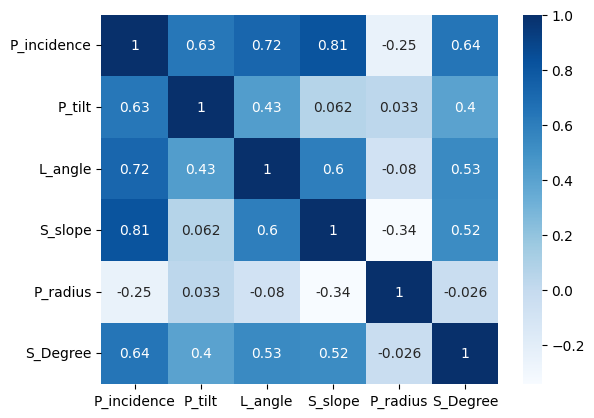

In [13]:
sns.heatmap(df.corr(numeric_only = True),cmap='Blues',annot=True);

#### 1. S_slope and P_incidence is having stronger positive correlation i.e. 0.81.
#### 2. L_angle and P_incidence is having stronger positive correlation i.e. 0.72.
#### 3. P_tilt is having weaker correlation with S_Slope and P_radius respectively with values 0.062 and 0.033.

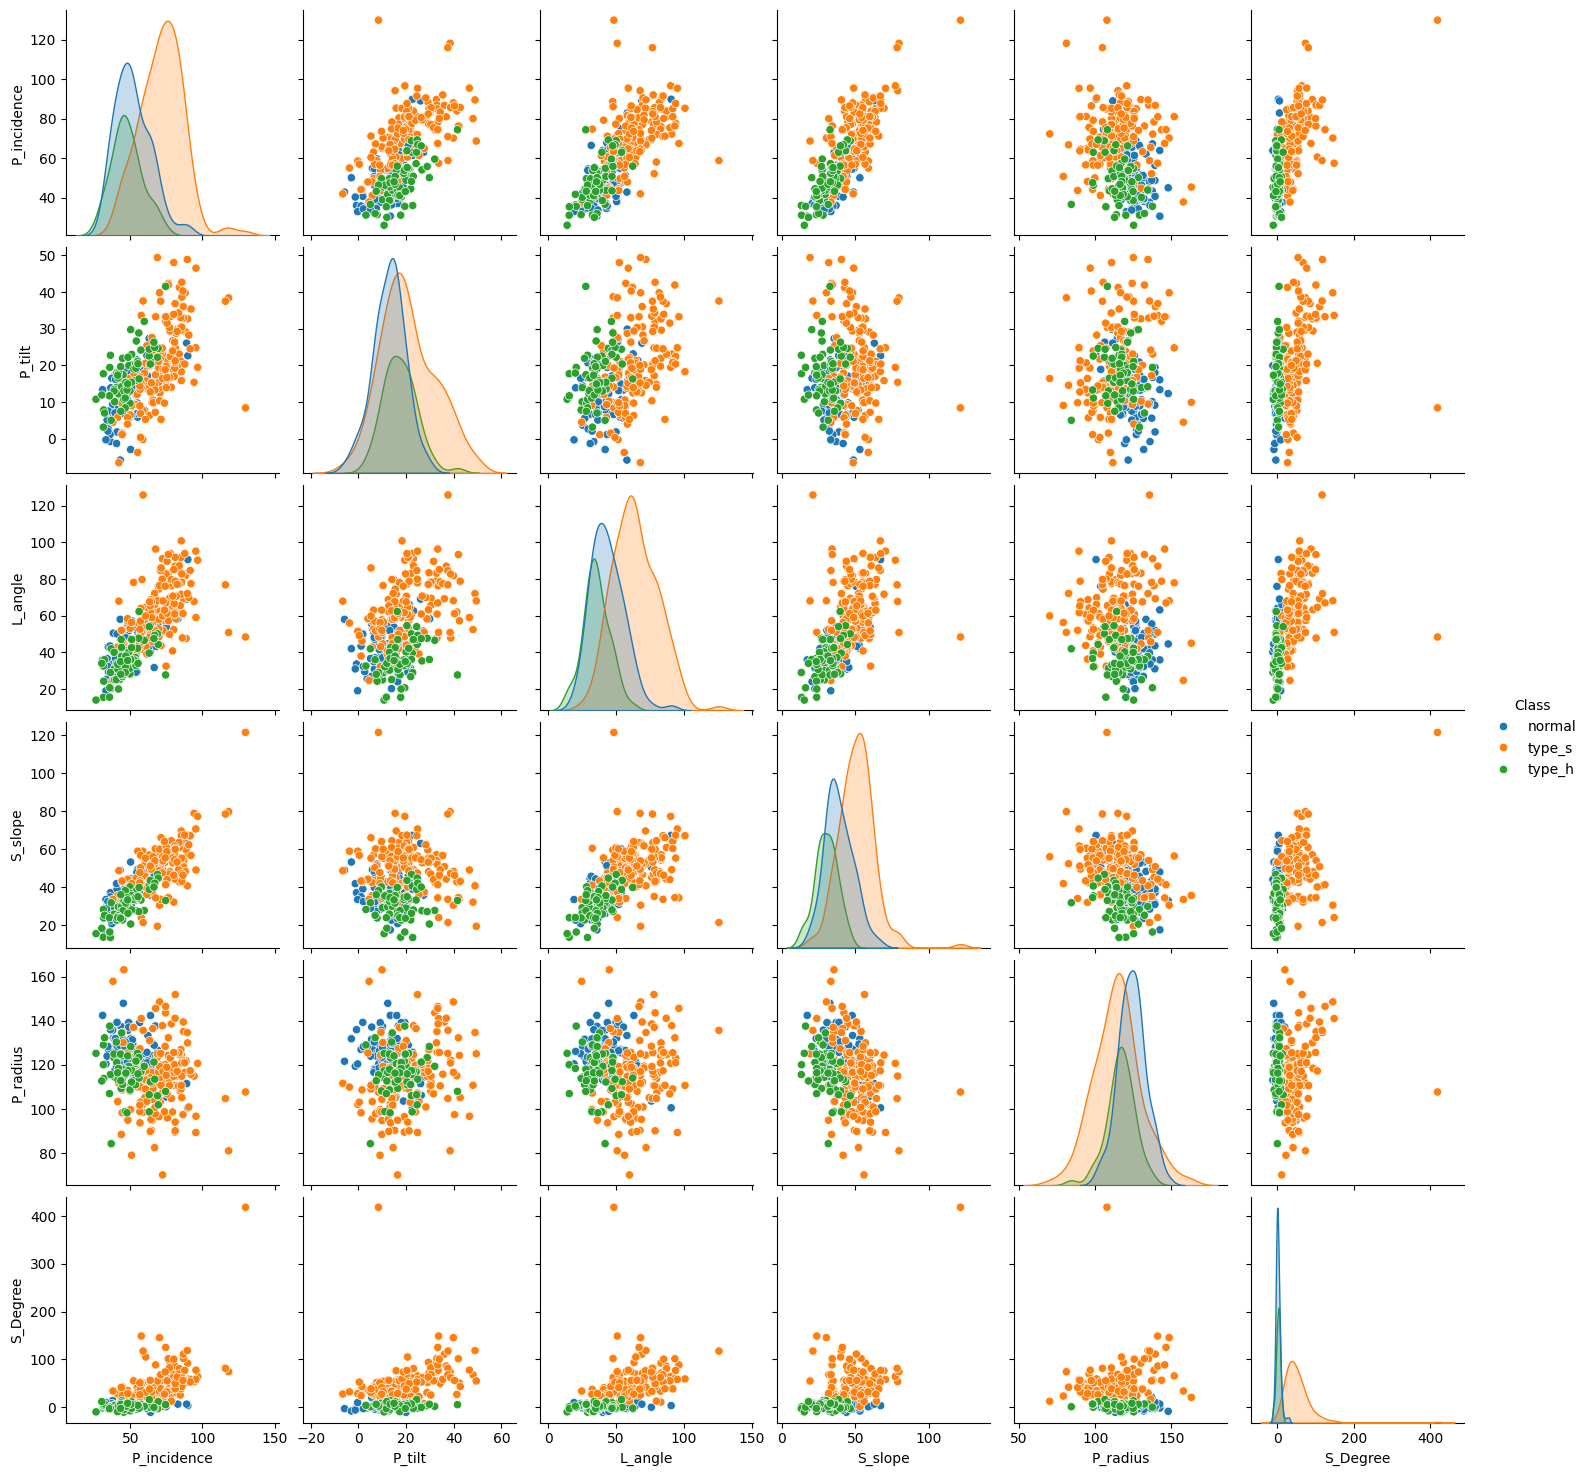

In [14]:
# Visualize a pairplot with 3 classes distinguished by colors and share insights.
sns.pairplot(df, diag_kind = 'kde', hue = 'Class');

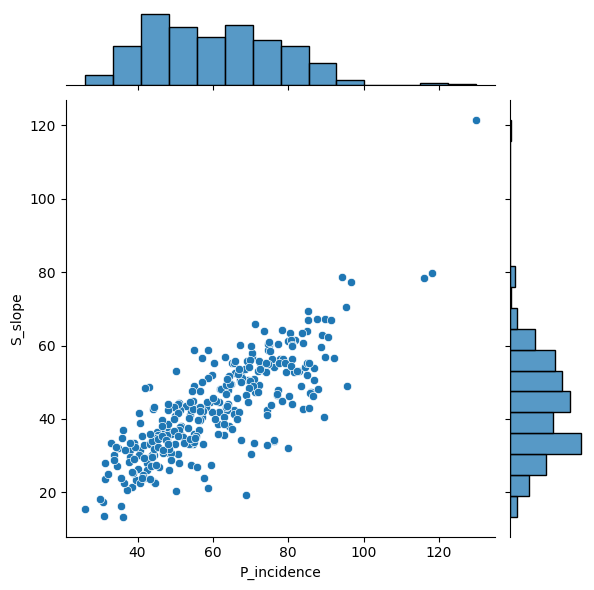

In [15]:
# Visualize a jointplot for ‘P_incidence’ and ‘S_slope’ and share insights.
sns.jointplot(x = 'P_incidence', y = 'S_slope', data = df);

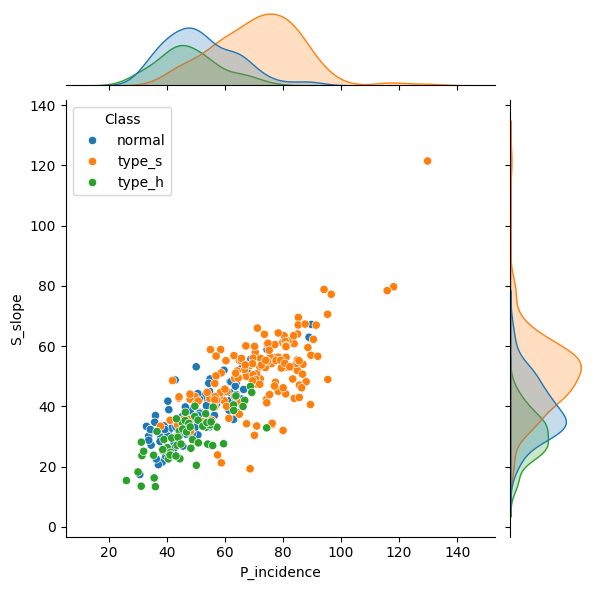

In [16]:
sns.jointplot(x = 'P_incidence', y = 'S_slope', data = df, hue = 'Class');

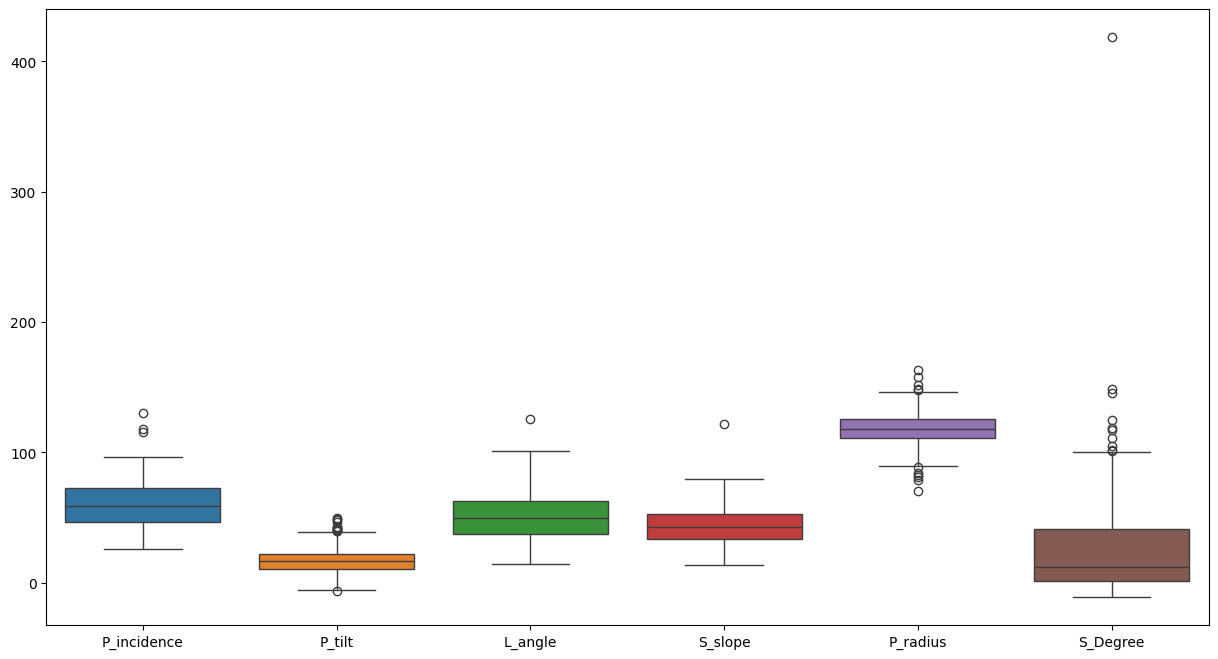

In [17]:
# Visualize a boxplot to check distribution of the features and share insights
plt.figure(figsize = (15,8))
sns.boxplot(data = df);

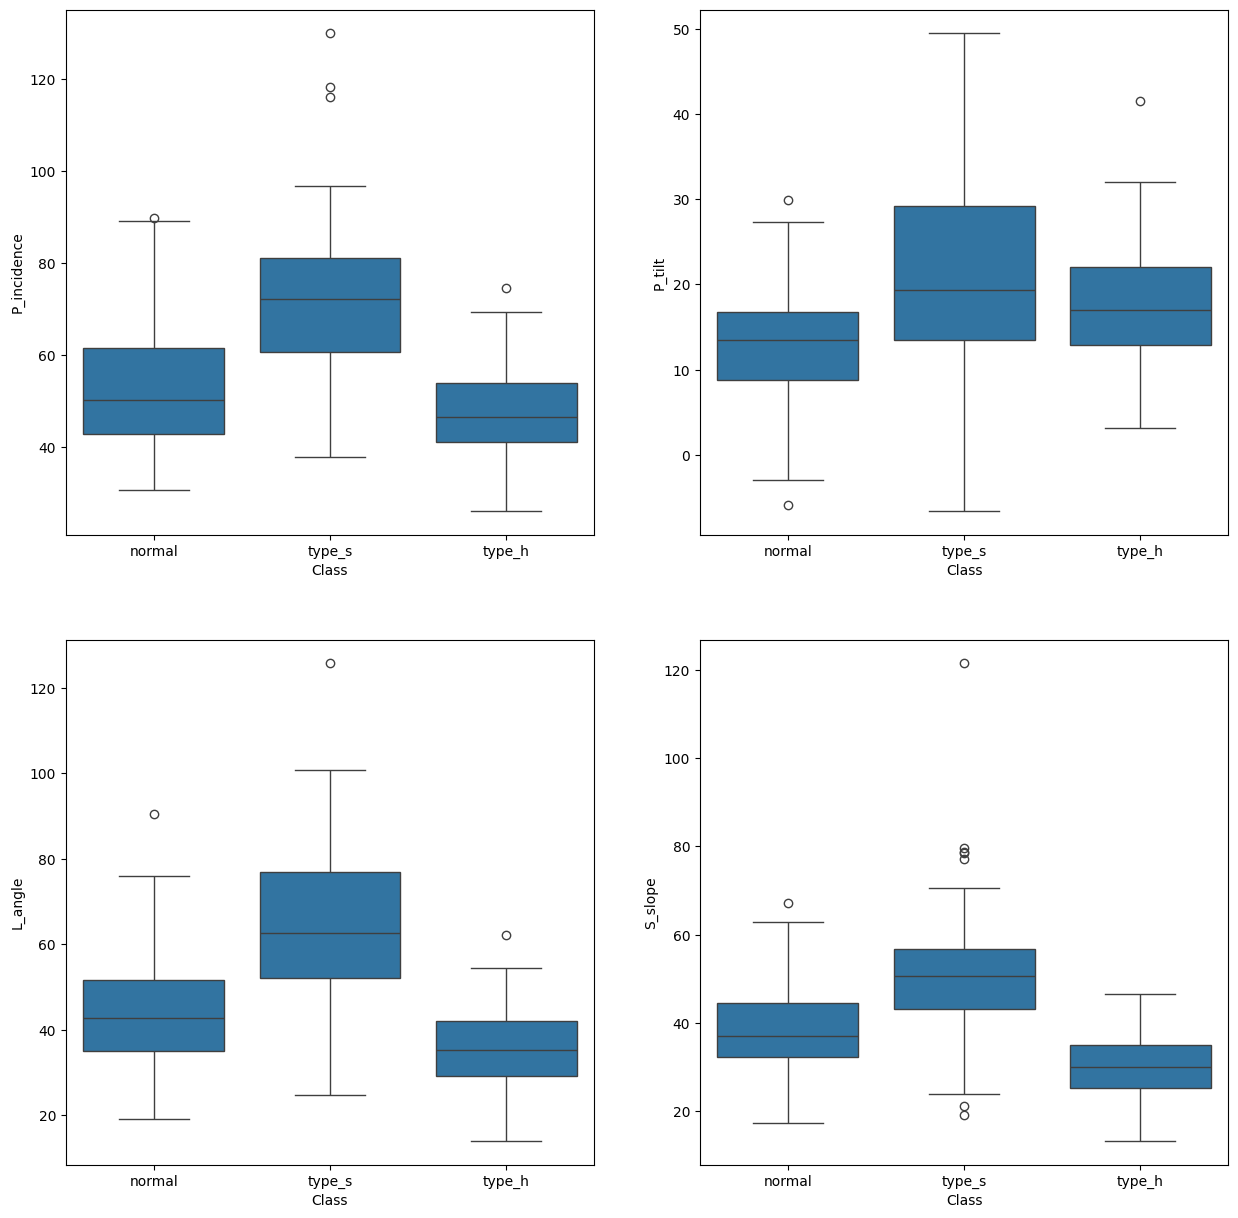

In [18]:
f, axes = plt.subplots(2, 2)
f.set_figheight(15)
f.set_figwidth(15)
sns.boxplot(y = "P_incidence", x = "Class", data = df, orient = 'v', ax = axes[0][0])
sns.boxplot(y = "P_tilt", x = "Class", data = df, orient = 'v', ax = axes[0][1])
sns.boxplot(y = "L_angle", x = "Class", data = df, orient = 'v', ax = axes[1][0])
sns.boxplot(y = "S_slope", x = "Class", data = df, orient = 'v', ax = axes[1][1])
plt.show()

### <a id="section_4"></a> 4. Model Building

In [19]:
# Seperating into X features and y target
X = df.drop('Class',axis=1)
y = df['Class']
# Splitting into Train-Test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 67, test_size = .2)

In [20]:
# Applying Z-score normalization on seperated train-test features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
knn_basic_model = KNeighborsClassifier()
knn_basic_model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [22]:
train_pred = knn_basic_model.predict(X_train_scaled)
test_pred = knn_basic_model.predict(X_test_scaled)

# Model Evaluation
print("Train Accuracy is: ", accuracy_score(y_train, train_pred))
print('*'*40)
print("Test Accuracy is: ", accuracy_score(y_test, test_pred))
print('*'*40)
print("Training metrics: \n", classification_report(y_train, train_pred))
print('*'*40)
print("Testing metrics: \n", classification_report(y_test, test_pred))
print('*'*40)

Train Accuracy is:  0.8588709677419355
****************************************
Test Accuracy is:  0.7741935483870968
****************************************
Training metrics: 
               precision    recall  f1-score   support

      normal       0.78      0.84      0.81        82
      type_h       0.76      0.78      0.77        45
      type_s       0.96      0.90      0.93       121

    accuracy                           0.86       248
   macro avg       0.83      0.84      0.84       248
weighted avg       0.86      0.86      0.86       248

****************************************
Testing metrics: 
               precision    recall  f1-score   support

      normal       0.67      0.67      0.67        18
      type_h       0.73      0.73      0.73        15
      type_s       0.86      0.86      0.86        29

    accuracy                           0.77        62
   macro avg       0.75      0.75      0.75        62
weighted avg       0.77      0.77      0.77        62


### 5. <a id="section_5"></a>Performance Improvement

In [23]:
knn_fine_tuned_model = KNeighborsClassifier(n_neighbors = 25, algorithm = 'ball_tree', weights = 'distance', p = 2)
knn_fine_tuned_model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",25
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'ball_tree'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [24]:
train_pred = knn_fine_tuned_model.predict(X_train_scaled)
test_pred = knn_fine_tuned_model.predict(X_test_scaled)

# Model Evaluation
print("Train Accuracy is: ", accuracy_score(y_train, train_pred))
print('*'*40)
print("Test Accuracy is: ", accuracy_score(y_test, test_pred))
print('*'*40)
print("Training metrics: \n", classification_report(y_train, train_pred))
print('*'*40)
print("Testing metrics: \n", classification_report(y_test, test_pred))
print('*'*40)

Train Accuracy is:  1.0
****************************************
Test Accuracy is:  0.7580645161290323
****************************************
Training metrics: 
               precision    recall  f1-score   support

      normal       1.00      1.00      1.00        82
      type_h       1.00      1.00      1.00        45
      type_s       1.00      1.00      1.00       121

    accuracy                           1.00       248
   macro avg       1.00      1.00      1.00       248
weighted avg       1.00      1.00      1.00       248

****************************************
Testing metrics: 
               precision    recall  f1-score   support

      normal       0.65      0.61      0.63        18
      type_h       0.71      0.67      0.69        15
      type_s       0.84      0.90      0.87        29

    accuracy                           0.76        62
   macro avg       0.73      0.72      0.73        62
weighted avg       0.75      0.76      0.75        62

**************

In [25]:
# Train a Supervised Learning Classification base model using KNN classifier.
knn_fine_tuned_model_2 = KNeighborsClassifier(n_neighbors = 11, weights = 'distance')
# fit the model with train data
knn_fine_tuned_model_2.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [26]:
train_pred = knn_fine_tuned_model_2.predict(X_train_scaled)
test_pred = knn_fine_tuned_model_2.predict(X_test_scaled)

# Model Evaluation
print("Train Accuracy is: ", accuracy_score(y_train, train_pred))
print('*'*40)
print("Test Accuracy is: ", accuracy_score(y_test, test_pred))
print('*'*40)
print("Training metrics: \n", classification_report(y_train, train_pred))
print('*'*40)
print("Testing metrics: \n", classification_report(y_test, test_pred))
print('*'*40)

Train Accuracy is:  1.0
****************************************
Test Accuracy is:  0.7741935483870968
****************************************
Training metrics: 
               precision    recall  f1-score   support

      normal       1.00      1.00      1.00        82
      type_h       1.00      1.00      1.00        45
      type_s       1.00      1.00      1.00       121

    accuracy                           1.00       248
   macro avg       1.00      1.00      1.00       248
weighted avg       1.00      1.00      1.00       248

****************************************
Testing metrics: 
               precision    recall  f1-score   support

      normal       0.69      0.61      0.65        18
      type_h       0.73      0.73      0.73        15
      type_s       0.84      0.90      0.87        29

    accuracy                           0.77        62
   macro avg       0.75      0.75      0.75        62
weighted avg       0.77      0.77      0.77        62

**************

In [27]:
knn_CV = KNeighborsClassifier()
# Set up GridSearchCV with 5-fold cross-validation
# 'cv=5' for 5 folds
# 'scoring="f1-score"' for the evaluation metric
param_grid = {'n_neighbors': np.arange(3, 27)}
grid_search = GridSearchCV(knn_CV, param_grid, cv = 5, scoring = 'f1_weighted')

# Applying Z-score normalization on X features
X_scaled = X.apply(zscore)

# Fit the GridSearchCV object to the data
# This step performs the cross-validation for all 'k' values
grid_search.fit(X_scaled, y)

# Print the best 'k' value and its corresponding accuracy
print("Best k value (n_neighbors):", grid_search.best_params_['n_neighbors'])
print("Best mean CV accuracy:", grid_search.best_score_)

# The best estimator is automatically refitted with the optimal 'k' on the entire training data
# You can use it for final predictions on a separate test set (if you had one initially split)
best_knn_model = grid_search.best_estimator_

Best k value (n_neighbors): 9
Best mean CV accuracy: 0.7953155946646217


In [28]:
# Train a Supervised Learning Classification base model using KNN classifier.
knn_optimized = KNeighborsClassifier(n_neighbors = 9, weights = 'distance')
# fit the model with train data
knn_optimized.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",9
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [29]:
train_pred = knn_optimized.predict(X_train_scaled)
test_pred = knn_optimized.predict(X_test_scaled)

# Model Evaluation
print("Train Accuracy is: ", accuracy_score(y_train, train_pred))
print('*'*40)
print("Test Accuracy is: ", accuracy_score(y_test, test_pred))
print('*'*40)
print("Training metrics: \n", classification_report(y_train, train_pred))
print('*'*40)
print("Testing metrics: \n", classification_report(y_test, test_pred))
print('*'*40)

Train Accuracy is:  1.0
****************************************
Test Accuracy is:  0.7580645161290323
****************************************
Training metrics: 
               precision    recall  f1-score   support

      normal       1.00      1.00      1.00        82
      type_h       1.00      1.00      1.00        45
      type_s       1.00      1.00      1.00       121

    accuracy                           1.00       248
   macro avg       1.00      1.00      1.00       248
weighted avg       1.00      1.00      1.00       248

****************************************
Testing metrics: 
               precision    recall  f1-score   support

      normal       0.67      0.67      0.67        18
      type_h       0.71      0.67      0.69        15
      type_s       0.83      0.86      0.85        29

    accuracy                           0.76        62
   macro avg       0.74      0.73      0.73        62
weighted avg       0.76      0.76      0.76        62

**************

### 6. <a id="section_6"></a>Save models

In [31]:
models = {"knn_basic_model": knn_basic_model, "knn_fine_tuned_model": knn_fine_tuned_model, "knn_fine_tuned_model_2": knn_fine_tuned_model_2, "knn_optimized": knn_optimized}

In [34]:
for model_name, model in models.items():
    pickle_out = open(f"models/{model_name}.pkl","wb")
    pickle.dump(model, pickle_out)
    pickle_out.close()